In [1]:
!pip install sentence-transformers seaborn matplotlib

In [2]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match.",
    "The bowler took three wickets in one over.",
    "The team won the cricket match by chasing the target.",
    "Fielding plays a crucial role in cricket matches.",

    # Cooking (3)
    "Cooking requires the right balance of spices.",
    "Boiling vegetables helps retain nutrients.",
    "Baking a cake needs precise measurements.",

    # Cybersecurity (3)
    "Cybersecurity protects systems from cyber attacks.",
    "Encryption ensures data confidentiality.",
    "Strong passwords help prevent unauthorized access."
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences, 1):
    print(f"{i}. {s}")

Total sentences: 10
1. The batsman scored a century in the match.
2. The bowler took three wickets in one over.
3. The team won the cricket match by chasing the target.
4. Fielding plays a crucial role in cricket matches.
5. Cooking requires the right balance of spices.
6. Boiling vegetables helps retain nutrients.
7. Baking a cake needs precise measurements.
8. Cybersecurity protects systems from cyber attacks.
9. Encryption ensures data confidentiality.
10. Strong passwords help prevent unauthorized access.


In [3]:
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Check shape
print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


Cosine Similarity Matrix:
 [[ 1.0000002   0.57997596  0.60293114  0.5803619   0.03089023  0.03023318
   0.12860927 -0.00960874 -0.01631634 -0.04475226]
 [ 0.57997596  1.          0.54959023  0.4440481   0.12690414  0.03777158
   0.09696174  0.00943884 -0.00638773 -0.01510059]
 [ 0.60293114  0.54959023  1.0000002   0.54975057  0.01338014  0.0318691
   0.0350959   0.06933644 -0.01685493 -0.09462425]
 [ 0.5803619   0.4440481   0.54975057  1.0000001   0.18186566  0.15214776
   0.06259037  0.02867895  0.03746675  0.05084917]
 [ 0.03089023  0.12690414  0.01338014  0.18186566  1.          0.361463
   0.2105596  -0.01087208  0.04034961  0.08226994]
 [ 0.03023318  0.03777158  0.0318691   0.15214776  0.361463    1.0000002
   0.06990087 -0.0233618   0.12964545  0.03782745]
 [ 0.12860927  0.09696174  0.0350959   0.06259037  0.2105596   0.06990087
   1.0000004  -0.03160824  0.09780781 -0.0359488 ]
 [-0.00960874  0.00943884  0.06933644  0.02867895 -0.01087208 -0.0233618
  -0.03160824  1.          0.

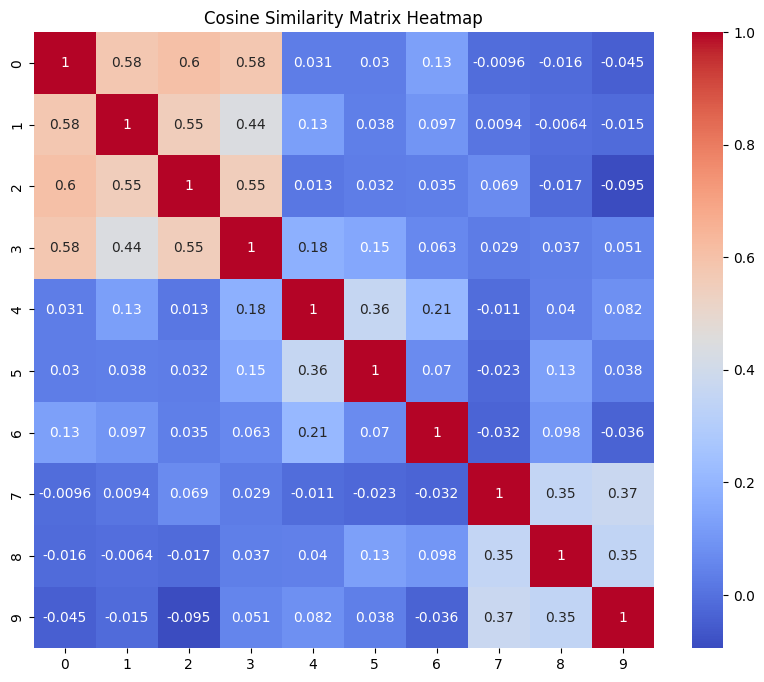

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Compute similarity
similarity_matrix = cosine_similarity(embeddings)

# Print matrix (optional but good for marks)
print("Cosine Similarity Matrix:\n", similarity_matrix)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix Heatmap")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"

# Convert query to embedding
query_embedding = model.encode([query])

# Compute similarity with all sentences
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 3 indices (including itself)
top_indices = similarities.argsort()[-3:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices[1:3]:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the match.
Similarity Score: 0.5611

Sentence: The team won the cricket match by chasing the target.
Similarity Score: 0.5245

